<img src="https://raw.githubusercontent.com/egiuse25/APS/main/logo_UNSAM.jpg" align="right" width="150" />

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº7
#### Emilia Giusepponi

## Consigna  
Usando el archivo ecg.mat que contiene un registro electrocardiográfico (ECG) registrado durante una prueba de esfuerzo, junto con una serie de variables descriptas a continuación. Diseñe y aplique los filtros digitales necesarios para mitigar las siguientes fuentes de contaminación:

- Ruido causado por el movimiento de los electrodos (Alta frecuencia).

- Ruido muscular (Alta frecuencia).

- Movimiento de la línea de base del ECG, inducido en parte por la respiración (Baja frecuencia).

**Ayuda:** Los detalles de cómo acceder a ecg.mat los pueden encontrar en lectura_sigs.py

**Archivo ECG.mat** 
(variables)

- **ecg_lead**: Registro de ECG muestreado a fs = 1 kHz durante una prueba de esfuerzo
- **qrs_pattern1**: Complejo de ondas QRS normal
- **heartbeat_pattern1**: Latido normal
- **heartbeat_pattern2**: Latido de origen ventricular
- **qrs_detections**: vector con las localizaciones (en # de muestras) donde ocurren los latidos

**Se pide:**


**a)** Establezca una plantilla de diseño para los filtros digitales que necesitará para que la señal de ECG se asemeje a los latidos promedio en cuanto a  suavidad de los trazos y nivel isoeléctrico nulo.

**Ayuda:** Utilice los resultados del ancho de banda estimado del ECG en la Tarea Semanal 5. Tome como referencia las siguientes morfologías promedio para evaluar cualitativamente la efectividad de los filtros diseñados.
 
**b)** ¿Cómo obtuvo dichos valores? Describa el procedimiento para establecer los valores de la plantilla.

**c)** Diseñe **al menos** dos filtros FIR y dos IIR para su comparación. Verifique que la respuesta en frecuencia responda a la plantilla de diseño.

**Ayuda:** Para los filtros IIR adopte las aproximaciones de módulo de máxima planicidad, Chebyshev y Cauer. Para los FIR, utilice las metodologías de ventanas, cuadrados mínimos y Parks-Mc Clellan-Remez. Todos implementados en SciPy.Signal

**d)**  Evalúe el rendimiento de los filtros que haya diseñado:

1. Verifique que filtra las señales interferentes.

2. Verifique que es inocuo en las zonas donde no hay interferentes.

**Ayuda:** Utilice el siguiente código como referencia para analizar los puntos 1 y 2). **También puede incluir otras regiones que considere de interés.**


#### Bonus:
- 💎 Proponga algún tipo de señal, ya sea de la TS anterior u otra que no haya sido analizada y repita el análisis. No olvide explicar su origen y cómo fue digitalizada.

## Desarrollo 

En principio, se estableció una plantilla de diseño para los filtros digitales pasabanda para que la señal de ECG se asemeje a los latidos promedio. Las frecuencias y atenuaciones elegidas fueron las siguientes: 

- Frecuencia de rechazo inferior (ws1): 0.1 Hz

- Frecuencia de paso inferior (wp1): 0.5 Hz

- Frecuencia de paso superior (wp2): 35 Hz

- Frecuencia de rechazo superior (ws2): 45 Hz

- Atenuación máxima en la banda de paso (gpass): 1 dB

- Atenuación mínima en la banda de rechazo (gstop): 40 dB

Se eligió una frecuencia de paso de 0.5 Hz para atenuar cualquier ruido proveniente del movimiento de la respiración del paciente.

Por otro lado, la frecuencia de paso superior se estableció a partir de 35 Hz hasta 45 Hz para no incluir al ruido muscular que comienza aproximadamente a partir de los 50 Hz. Se eligieron los 35 Hz basándose en análisis previos en los cuales se observó que con el 99% de la energía el ancho de banda del ECG se encontraba en 31.1 Hz. 

### Filtros de tipo IIR

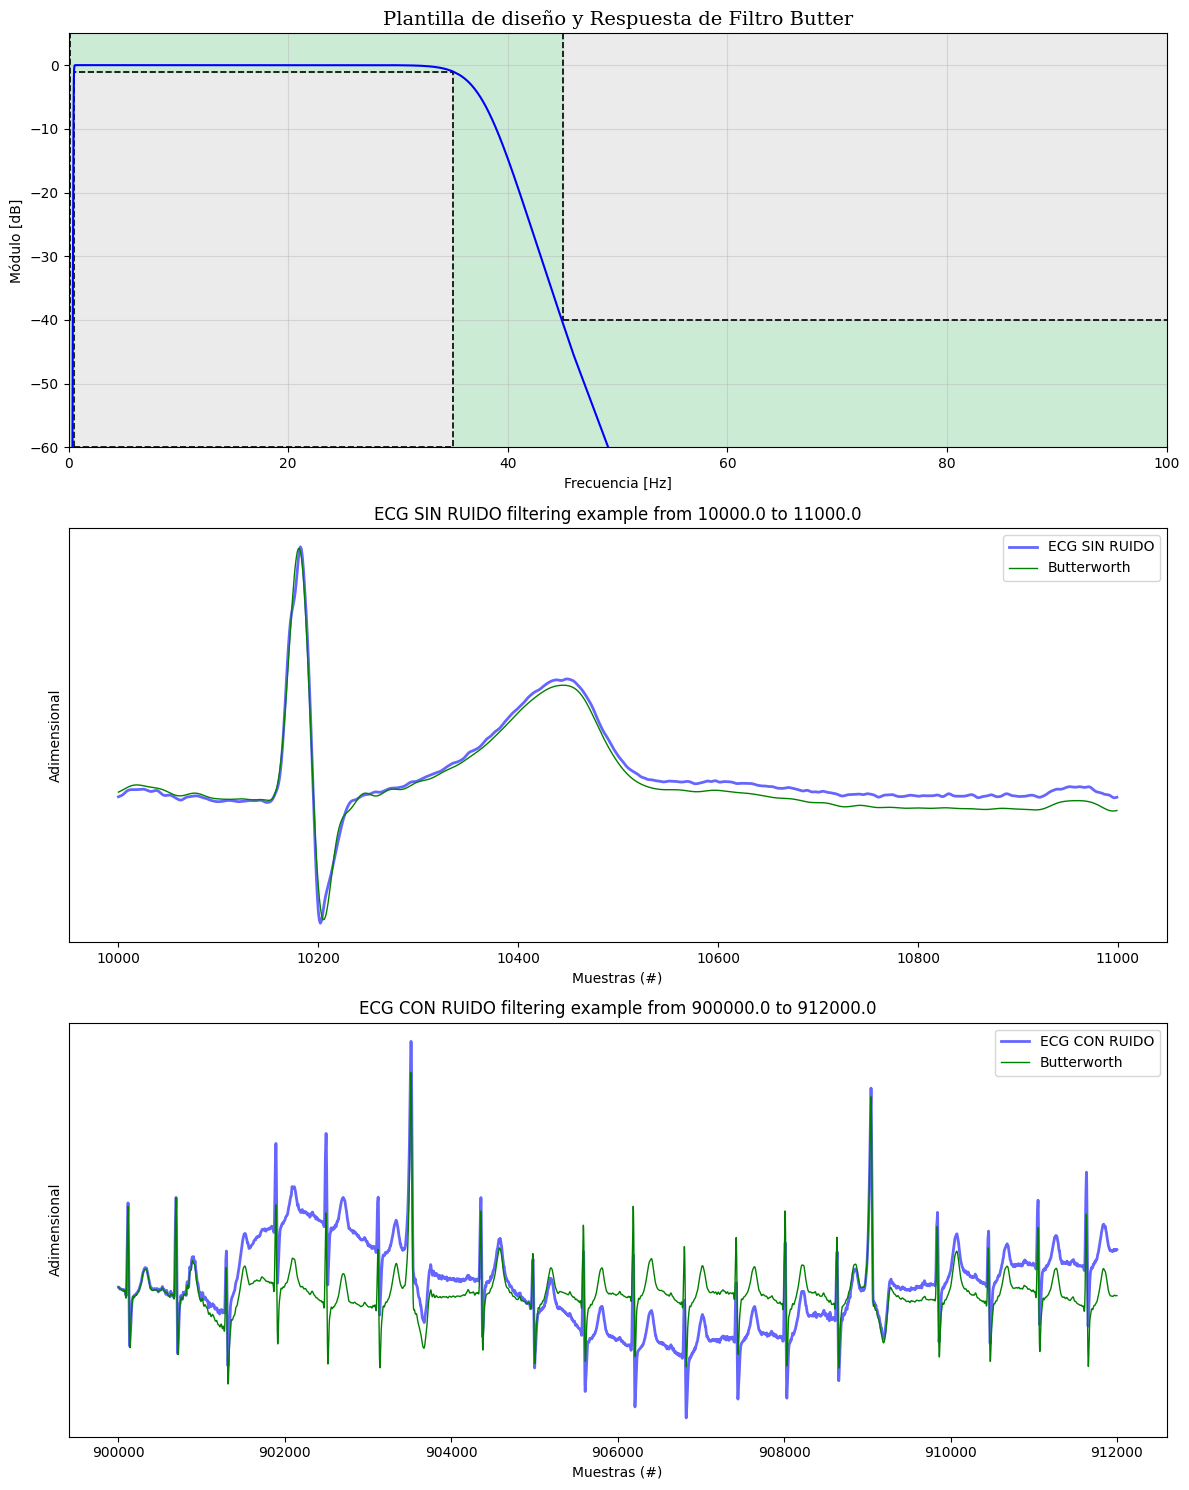

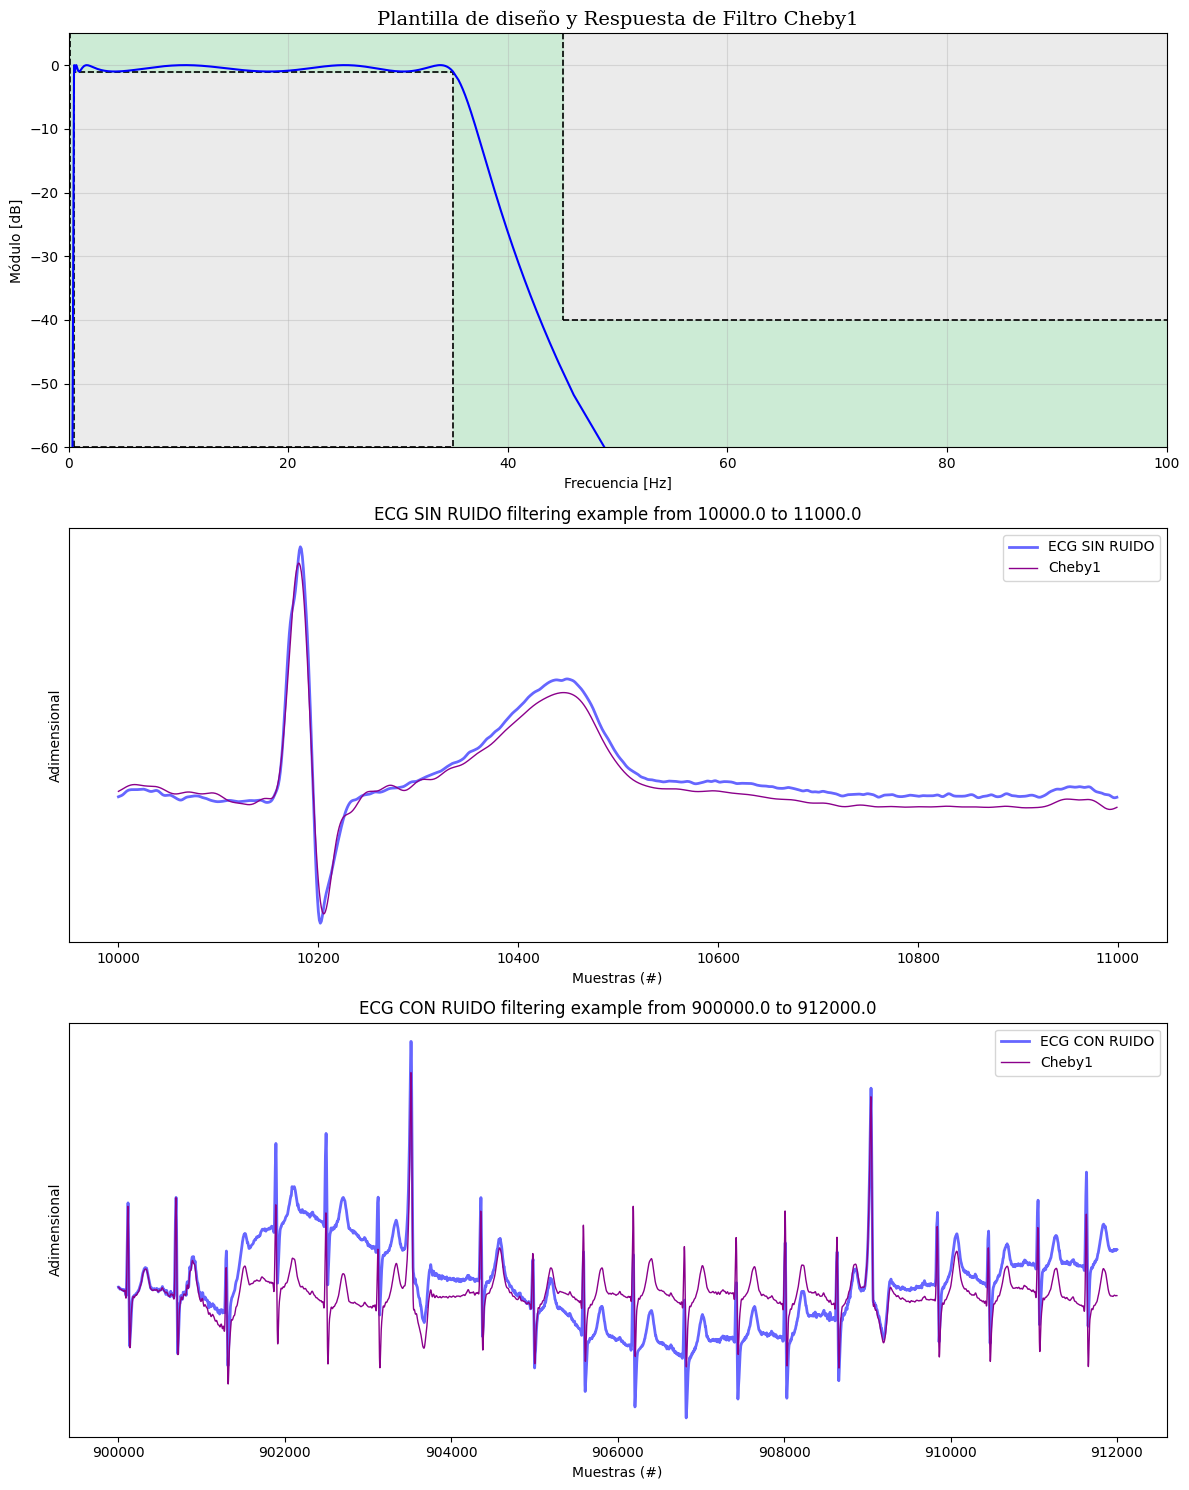

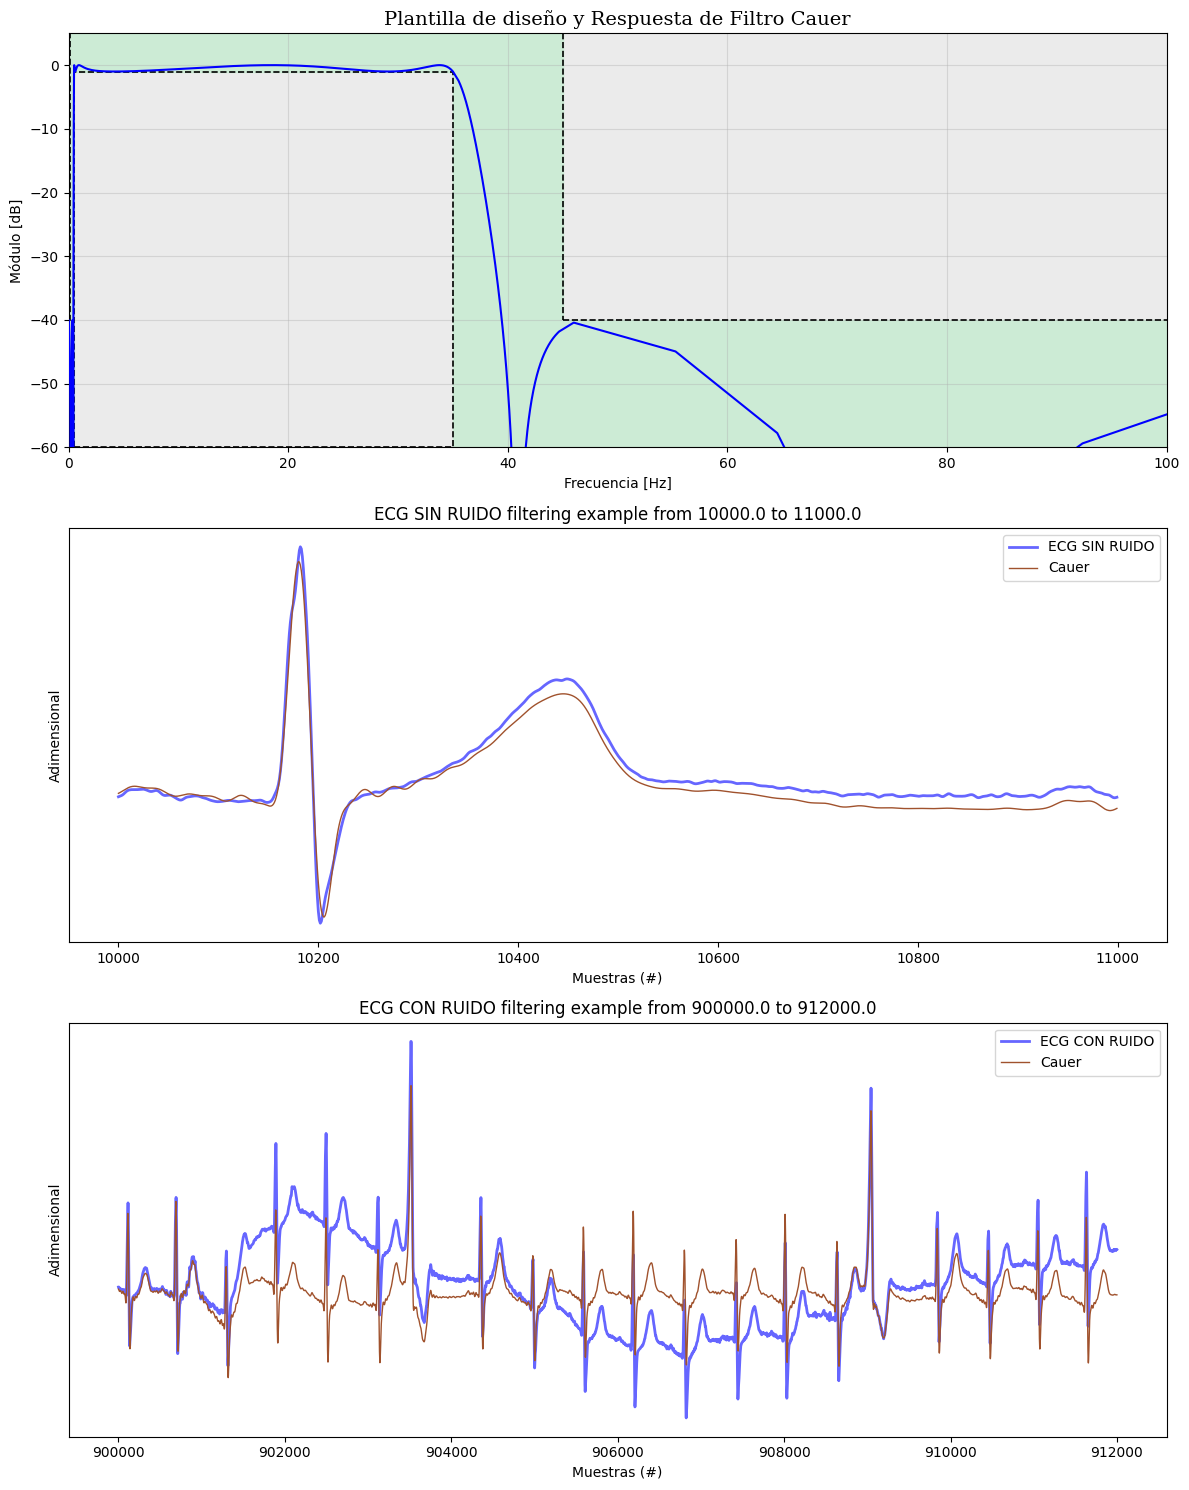

Orden del filtro Butterworth: 26
Orden del filtro Chebyshev I: 12
Orden del filtro Cauer: 8


In [37]:
'-----DISEÑO FILTRO BUTTERWORTH----'
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig 
import scipy.io as sio  

fs_butter = 1000

ws1_butter = .1 # STOP
wp1_butter = .5 # PASO
ws2_butter = 45 # STOP
wp2_butter = 35 # PASO

wp_butter = [wp1_butter, wp2_butter]
ws_butter = [ws1_butter, ws2_butter]

gpass_butter = 1
gstop_butter = 40


ww = np.concatenate([
    np.logspace(start=-2, stop=0.1, num=500), 
    np.linspace(start=1.26, stop=35, num=200),
    np.logspace(start=1.55, stop=1.65, num=300),
    np.linspace(start=46, stop=fs//2, num=50)]) 

sos_coeff_butt = sig.iirdesign(wp=wp_butter, ws=ws_butter, gpass=gpass_butter/2, gstop=gstop_butter/2, analog=False, ftype='butter', output='sos', fs=fs_butter)

w_butter, h_butter = sig.sosfreqz(sos_coeff_butt, worN=ww, fs=fs)

wp_butter = [wp1_butter, wp2_butter]
ws_butter = [ws1_butter, ws2_butter]

w_butt, h_butt = sig.sosfreqz(sos_coeff_butt, worN=ww, fs=fs_butter)

yy_butt = sig.sosfiltfilt(sos_coeff_butt, ecg_one_lead)

ECG_f_butt = yy_butt


'------GRAFICO------'
fig, axs = plt.subplots(3, 1, figsize=(12, 15))

ax_plantilla = axs[0]
ax_plantilla.set_facecolor('#ebebeb') 

ax_plantilla.fill_between([0, ws1_butter], -60, -gstop_butter, color='#ccebd5', zorder=1)
ax_plantilla.fill_between([ws1_butter, wp1_butter], -60, 5, color='#ccebd5', zorder=1)
ax_plantilla.fill_between([wp1_butter, wp2_butter], -ripple, 5, color='#ccebd5', zorder=1)
ax_plantilla.fill_between([wp2_butter, ws2_butter], -60, 5, color='#ccebd5', zorder=1)
ax_plantilla.fill_between([ws2_butter, fs_butter//2], -60, -gstop_butter, color='#ccebd5', zorder=1)

rect_stop1 = patches.Rectangle((0, -gstop_butter), ws1_butter, 5 - (-gstop_butter), 
                               linewidth=1.2, edgecolor='black', linestyle='--', facecolor='none', zorder=2)
ax_plantilla.add_patch(rect_stop1)

rect_pass = patches.Rectangle((wp1_butter, -60), wp2_butter - wp1_butter, (-ripple) - (-60), 
                              linewidth=1.2, edgecolor='black', linestyle='--', facecolor='none', zorder=2)
ax_plantilla.add_patch(rect_pass)

rect_stop2 = patches.Rectangle((ws2_butter, -gstop_butter), (fs_butter//2) - ws2_butter, 5 - (-gstop_butter), 
                               linewidth=1.2, edgecolor='black', linestyle='--', facecolor='none', zorder=2)
ax_plantilla.add_patch(rect_stop2)

mag_db_butter = 20 * np.log10(np.maximum(np.abs(h_butter)**2, 1e-12))

ax_plantilla.plot(w_butter, mag_db_butter, color='blue', linewidth=1.5, label='FIR Window', zorder=3)

ax_plantilla.set_title("Plantilla de diseño y Respuesta de Filtro Butter", fontfamily='serif', fontsize=14)
ax_plantilla.set_xlabel("Frecuencia [Hz]")
ax_plantilla.set_ylabel("Módulo [dB]")
ax_plantilla.set_xlim(0, 100) 
ax_plantilla.set_ylim(-60, 5)
ax_plantilla.grid(True, linestyle='-', alpha=0.4, zorder=0)

green_patch = patches.Patch(color='#ccebd5', label='bw digital')
dashed_line = mlines.Line2D([], [], color='none', markeredgecolor='black', marker='s', markersize=12, markeredgewidth=1.2, linestyle='--', label='Plantilla')
blue_line = mlines.Line2D([], [], color='blue', linewidth=1.5, label='IIR Butter')


'----COMPARACION FILTRO----'
ii_sin_ruido = [10e3, 11e3] 
zoom_region = np.arange(np.max([0, ii_sin_ruido[0]]), np.min([cant_muestras, ii_sin_ruido[1]]), dtype='uint')

axs[1].plot(zoom_region, ecg_one_lead[zoom_region], label='ECG SIN RUIDO', color='blue', alpha=0.6, linewidth=2)
axs[1].plot(zoom_region, ECG_f_butt[zoom_region], label='Butterworth', color='green', linewidth=1)

axs[1].set_title('ECG SIN RUIDO filtering example from ' + str(ii_sin_ruido[0]) + ' to ' + str(ii_sin_ruido[1]))
axs[1].set_ylabel('Adimensional')
axs[1].set_xlabel('Muestras (#)')
axs[1].legend(loc='upper right')
axs[1].set_yticks(())


ii_con_ruido = np.array([15, 15.2]) * 60 * fs 
zoom_region = np.arange(np.max([0, ii_con_ruido[0]]), np.min([cant_muestras, ii_con_ruido[1]]), dtype='uint')

axs[2].plot(zoom_region, ecg_one_lead[zoom_region], label='ECG CON RUIDO', color='blue', alpha=0.6, linewidth=2)
axs[2].plot(zoom_region, ECG_f_butt[zoom_region], label='Butterworth', color='green', linewidth=1)

axs[2].set_title('ECG CON RUIDO filtering example from ' + str(ii_con_ruido[0]) + ' to ' + str(ii_con_ruido[1]))
axs[2].set_ylabel('Adimensional')
axs[2].set_xlabel('Muestras (#)')
axs[2].legend(loc='upper right')
axs[2].set_yticks(())

plt.tight_layout()
plt.show()


'-----DISEÑO FILTRO CHEBY1----'
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig 
import scipy.io as sio  

fs_cheby1 = 1000

ws1_cheby1 = .1 # STOP
wp1_cheby1 = .5 # PASO
ws2_cheby1 = 45 # STOP
wp2_cheby1 = 35 # PASO

wp_cheby1 = [wp1_cheby1, wp2_cheby1]
ws_cheby1 = [ws1_cheby1, ws2_cheby1]

gpass_cheby1 = 1
gstop_cheby1 = 40


ww = np.concatenate([
    np.logspace(start=-2, stop=0.1, num=500), 
    np.linspace(start=1.26, stop=35, num=200),
    np.logspace(start=1.55, stop=1.65, num=300),
    np.linspace(start=46, stop=fs//2, num=50)]) 

sos_coeff_cheby1 = sig.iirdesign(wp=wp_cheby1, ws=ws_cheby1, gpass=gpass_cheby1/2, gstop=gstop_cheby1/2, analog=False, ftype='cheby1', output='sos', fs=fs_cheby1)

wp_cheby1 = [wp1_cheby1, wp2_cheby1]
ws_cheby1 = [ws1_cheby1, ws2_cheby1]

w_cheby1, h_cheby1 = sig.sosfreqz(sos_coeff_cheby1, worN=ww, fs=fs_cheby1)

yy_cheby1 = sig.sosfiltfilt(sos_coeff_cheby1, ecg_one_lead)

ECG_f_cheby1 = yy_cheby1


'------GRAFICO------'
fig, axs = plt.subplots(3, 1, figsize=(12, 15))

ax_plantilla = axs[0]
ax_plantilla.set_facecolor('#ebebeb') 

ax_plantilla.fill_between([0, ws1_cheby1], -60, -gstop_cheby1, color='#ccebd5', zorder=1)
ax_plantilla.fill_between([ws1_cheby1, wp1_cheby1], -60, 5, color='#ccebd5', zorder=1)
ax_plantilla.fill_between([wp1_cheby1, wp2_cheby1], -ripple, 5, color='#ccebd5', zorder=1)
ax_plantilla.fill_between([wp2_cheby1, ws2_cheby1], -60, 5, color='#ccebd5', zorder=1)
ax_plantilla.fill_between([ws2_cheby1, fs_cheby1//2], -60, -gstop_cheby1, color='#ccebd5', zorder=1)

rect_stop1 = patches.Rectangle((0, -gstop_cheby1), ws1_cheby1, 5 - (-gstop_cheby1), 
                               linewidth=1.2, edgecolor='black', linestyle='--', facecolor='none', zorder=2)
ax_plantilla.add_patch(rect_stop1)

rect_pass = patches.Rectangle((wp1_cheby1, -60), wp2_cheby1 - wp1_cheby1, (-ripple) - (-60), 
                              linewidth=1.2, edgecolor='black', linestyle='--', facecolor='none', zorder=2)
ax_plantilla.add_patch(rect_pass)

rect_stop2 = patches.Rectangle((ws2_cheby1, -gstop_cheby1), (fs_cheby1//2) - ws2_cheby1, 5 - (-gstop_cheby1), 
                               linewidth=1.2, edgecolor='black', linestyle='--', facecolor='none', zorder=2)
ax_plantilla.add_patch(rect_stop2)

mag_db_cheby1 = 20 * np.log10(np.maximum(np.abs(h_cheby1)**2, 1e-12))

ax_plantilla.plot(w_cheby1, mag_db_cheby1, color='blue', linewidth=1.5, label='FIR Window', zorder=3)

ax_plantilla.set_title("Plantilla de diseño y Respuesta de Filtro Cheby1", fontfamily='serif', fontsize=14)
ax_plantilla.set_xlabel("Frecuencia [Hz]")
ax_plantilla.set_ylabel("Módulo [dB]")
ax_plantilla.set_xlim(0, 100) 
ax_plantilla.set_ylim(-60, 5)
ax_plantilla.grid(True, linestyle='-', alpha=0.4, zorder=0)

green_patch = patches.Patch(color='#ccebd5', label='bw digital')
dashed_line = mlines.Line2D([], [], color='none', markeredgecolor='black', marker='s', markersize=12, markeredgewidth=1.2, linestyle='--', label='Plantilla')
blue_line = mlines.Line2D([], [], color='blue', linewidth=1.5, label='IIR Cheby1')

regs_interes = (
        np.array([5, 5.2]) *60*fs, # minutos a muestras
        np.array([12, 12.4]) *60*fs, # minutos a muestras
        np.array([15, 15.2]) *60*fs, # minutos a muestras
        )
 

'----COMPARACION FILTRO----'
ii_sin_ruido = [10e3, 11e3] 
zoom_region = np.arange(np.max([0, ii_sin_ruido[0]]), np.min([cant_muestras, ii_sin_ruido[1]]), dtype='uint')

axs[1].plot(zoom_region, ecg_one_lead[zoom_region], label='ECG SIN RUIDO', color='blue', alpha=0.6, linewidth=2)
axs[1].plot(zoom_region, ECG_f_cheby1[zoom_region], label='Cheby1', color='darkmagenta', linewidth=1)

axs[1].set_title('ECG SIN RUIDO filtering example from ' + str(ii_sin_ruido[0]) + ' to ' + str(ii_sin_ruido[1]))
axs[1].set_ylabel('Adimensional')
axs[1].set_xlabel('Muestras (#)')
axs[1].legend(loc='upper right')
axs[1].set_yticks(())


ii_con_ruido = np.array([15, 15.2]) * 60 * fs 
zoom_region = np.arange(np.max([0, ii_con_ruido[0]]), np.min([cant_muestras, ii_con_ruido[1]]), dtype='uint')

axs[2].plot(zoom_region, ecg_one_lead[zoom_region], label='ECG CON RUIDO', color='blue', alpha=0.6, linewidth=2)
axs[2].plot(zoom_region, ECG_f_butt[zoom_region], label='Cheby1', color='darkmagenta', linewidth=1)

axs[2].set_title('ECG CON RUIDO filtering example from ' + str(ii_con_ruido[0]) + ' to ' + str(ii_con_ruido[1]))
axs[2].set_ylabel('Adimensional')
axs[2].set_xlabel('Muestras (#)')
axs[2].legend(loc='upper right')
axs[2].set_yticks(())

plt.tight_layout()
plt.show()


'-----DISEÑO FILTRO CAUER----'
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig 
import scipy.io as sio  

fs_cauer = 1000

ws1_cauer = .1 # STOP
wp1_cauer = .5 # PASO
ws2_cauer = 45 # STOP
wp2_cauer = 35 # PASO

wp_cauer = [wp1_cauer, wp2_cauer]
ws_cauer = [ws1_cauer, ws2_cauer]

gpass_cauer = 1
gstop_cauer = 40


ww = np.concatenate([
    np.logspace(start=-2, stop=0.1, num=500), 
    np.linspace(start=1.26, stop=35, num=200),
    np.logspace(start=1.55, stop=1.65, num=300),
    np.linspace(start=46, stop=fs//2, num=50)]) 

sos_coeff_cauer = sig.iirdesign(wp=wp_cauer, ws=ws_cauer, gpass=gpass_cauer/2, gstop=gstop_cauer/2, analog=False, ftype='cauer', output='sos', fs=fs_cauer)

w_cauer, h_cauer = sig.sosfreqz(sos_coeff_cauer, worN=ww, fs=fs)

wp_cauer = [wp1_cauer, wp2_cauer]
ws_cauer = [ws1_cauer, ws2_cauer]

w_cauer, h_cauer = sig.sosfreqz(sos_coeff_cauer, worN=ww, fs=fs_cauer)

yy_cauer = sig.sosfiltfilt(sos_coeff_cauer, ecg_one_lead)

ECG_f_cauer = yy_cauer


'------GRAFICO------'
fig, axs = plt.subplots(3, 1, figsize=(12, 15))

ax_plantilla = axs[0]
ax_plantilla.set_facecolor('#ebebeb') 

ax_plantilla.fill_between([0, ws1_cauer], -60, -gstop_cauer, color='#ccebd5', zorder=1)
ax_plantilla.fill_between([ws1_cauer, wp1_cauer], -60, 5, color='#ccebd5', zorder=1)
ax_plantilla.fill_between([wp1_cauer, wp2_cauer], -ripple, 5, color='#ccebd5', zorder=1)
ax_plantilla.fill_between([wp2_cauer, ws2_cauer], -60, 5, color='#ccebd5', zorder=1)
ax_plantilla.fill_between([ws2_cauer, fs_cauer//2], -60, -gstop_cauer, color='#ccebd5', zorder=1)

rect_stop1 = patches.Rectangle((0, -gstop_cauer), ws1_cauer, 5 - (-gstop_cauer), 
                               linewidth=1.2, edgecolor='black', linestyle='--', facecolor='none', zorder=2)
ax_plantilla.add_patch(rect_stop1)

rect_pass = patches.Rectangle((wp1_cauer, -60), wp2_cauer - wp1_cauer, (-ripple) - (-60), 
                              linewidth=1.2, edgecolor='black', linestyle='--', facecolor='none', zorder=2)
ax_plantilla.add_patch(rect_pass)

rect_stop2 = patches.Rectangle((ws2_cauer, -gstop_cauer), (fs_cauer//2) - ws2_cauer, 5 - (-gstop_cauer), 
                               linewidth=1.2, edgecolor='black', linestyle='--', facecolor='none', zorder=2)
ax_plantilla.add_patch(rect_stop2)

mag_db_cauer = 20 * np.log10(np.maximum(np.abs(h_cauer)**2, 1e-12))

ax_plantilla.plot(w_cauer, mag_db_cauer, color='blue', linewidth=1.5, label='FIR Window', zorder=3)

ax_plantilla.set_title("Plantilla de diseño y Respuesta de Filtro Cauer", fontfamily='serif', fontsize=14)
ax_plantilla.set_xlabel("Frecuencia [Hz]")
ax_plantilla.set_ylabel("Módulo [dB]")
ax_plantilla.set_xlim(0, 100) 
ax_plantilla.set_ylim(-60, 5)
ax_plantilla.grid(True, linestyle='-', alpha=0.4, zorder=0)

green_patch = patches.Patch(color='#ccebd5', label='bw digital')
dashed_line = mlines.Line2D([], [], color='none', markeredgecolor='black', marker='s', markersize=12, markeredgewidth=1.2, linestyle='--', label='Plantilla')
blue_line = mlines.Line2D([], [], color='blue', linewidth=1.5, label='IIR Cauer')

regs_interes = (
        np.array([5, 5.2]) *60*fs, # minutos a muestras
        np.array([12, 12.4]) *60*fs, # minutos a muestras
        np.array([15, 15.2]) *60*fs, # minutos a muestras
        )
 

'----COMPARACION FILTRO----'
ii_sin_ruido = [10e3, 11e3] 
zoom_region = np.arange(np.max([0, ii_sin_ruido[0]]), np.min([cant_muestras, ii_sin_ruido[1]]), dtype='uint')

axs[1].plot(zoom_region, ecg_one_lead[zoom_region], label='ECG SIN RUIDO', color='blue', alpha=0.6, linewidth=2)
axs[1].plot(zoom_region, ECG_f_cauer[zoom_region], label='Cauer', color='sienna', linewidth=1)

axs[1].set_title('ECG SIN RUIDO filtering example from ' + str(ii_sin_ruido[0]) + ' to ' + str(ii_sin_ruido[1]))
axs[1].set_ylabel('Adimensional')
axs[1].set_xlabel('Muestras (#)')
axs[1].legend(loc='upper right')
axs[1].set_yticks(())


ii_con_ruido = np.array([15, 15.2]) * 60 * fs 
zoom_region = np.arange(np.max([0, ii_con_ruido[0]]), np.min([cant_muestras, ii_con_ruido[1]]), dtype='uint')

axs[2].plot(zoom_region, ecg_one_lead[zoom_region], label='ECG CON RUIDO', color='blue', alpha=0.6, linewidth=2)
axs[2].plot(zoom_region, ECG_f_cauer[zoom_region], label='Cauer', color='sienna', linewidth=1)

axs[2].set_title('ECG CON RUIDO filtering example from ' + str(ii_con_ruido[0]) + ' to ' + str(ii_con_ruido[1]))
axs[2].set_ylabel('Adimensional')
axs[2].set_xlabel('Muestras (#)')
axs[2].legend(loc='upper right')
axs[2].set_yticks(())

plt.tight_layout()
plt.show()

orden_butter = sos_coeff_butt.shape[0] * 2
orden_cheby = sos_coeff_cheby1.shape[0] * 2
orden_cauer = sos_coeff_cauer.shape[0] * 2

print(f"Orden del filtro Butterworth: {orden_butter}")
print(f"Orden del filtro Chebyshev I: {orden_cheby}")
print(f"Orden del filtro Cauer: {orden_cauer}")


Si bien todos los filtros de respuesta infinita tuvieron un desempeño similar al filtrar la señal del electrocardiograma en el dominio del tiempo, al observar el gráfico de su respuesta en módulo se denota que Chebyshev de tipo I presenta ripple en la banda de paso mientras que Cauer lo presenta tanto en la banda de paso como en la de rechazo. Por otro lado, Butterworth presenta máxima planicidad en su respuesta en módulo. 

Por otro lado, en cuanto al costo computacional, el filtro de Cauer logra satisfacer la plantilla con el menor orden computacional, siendo la opción más eficiente, mientras que Butterworth requiere un orden considerablemente mayor.

### Filtros de tipo FIR 

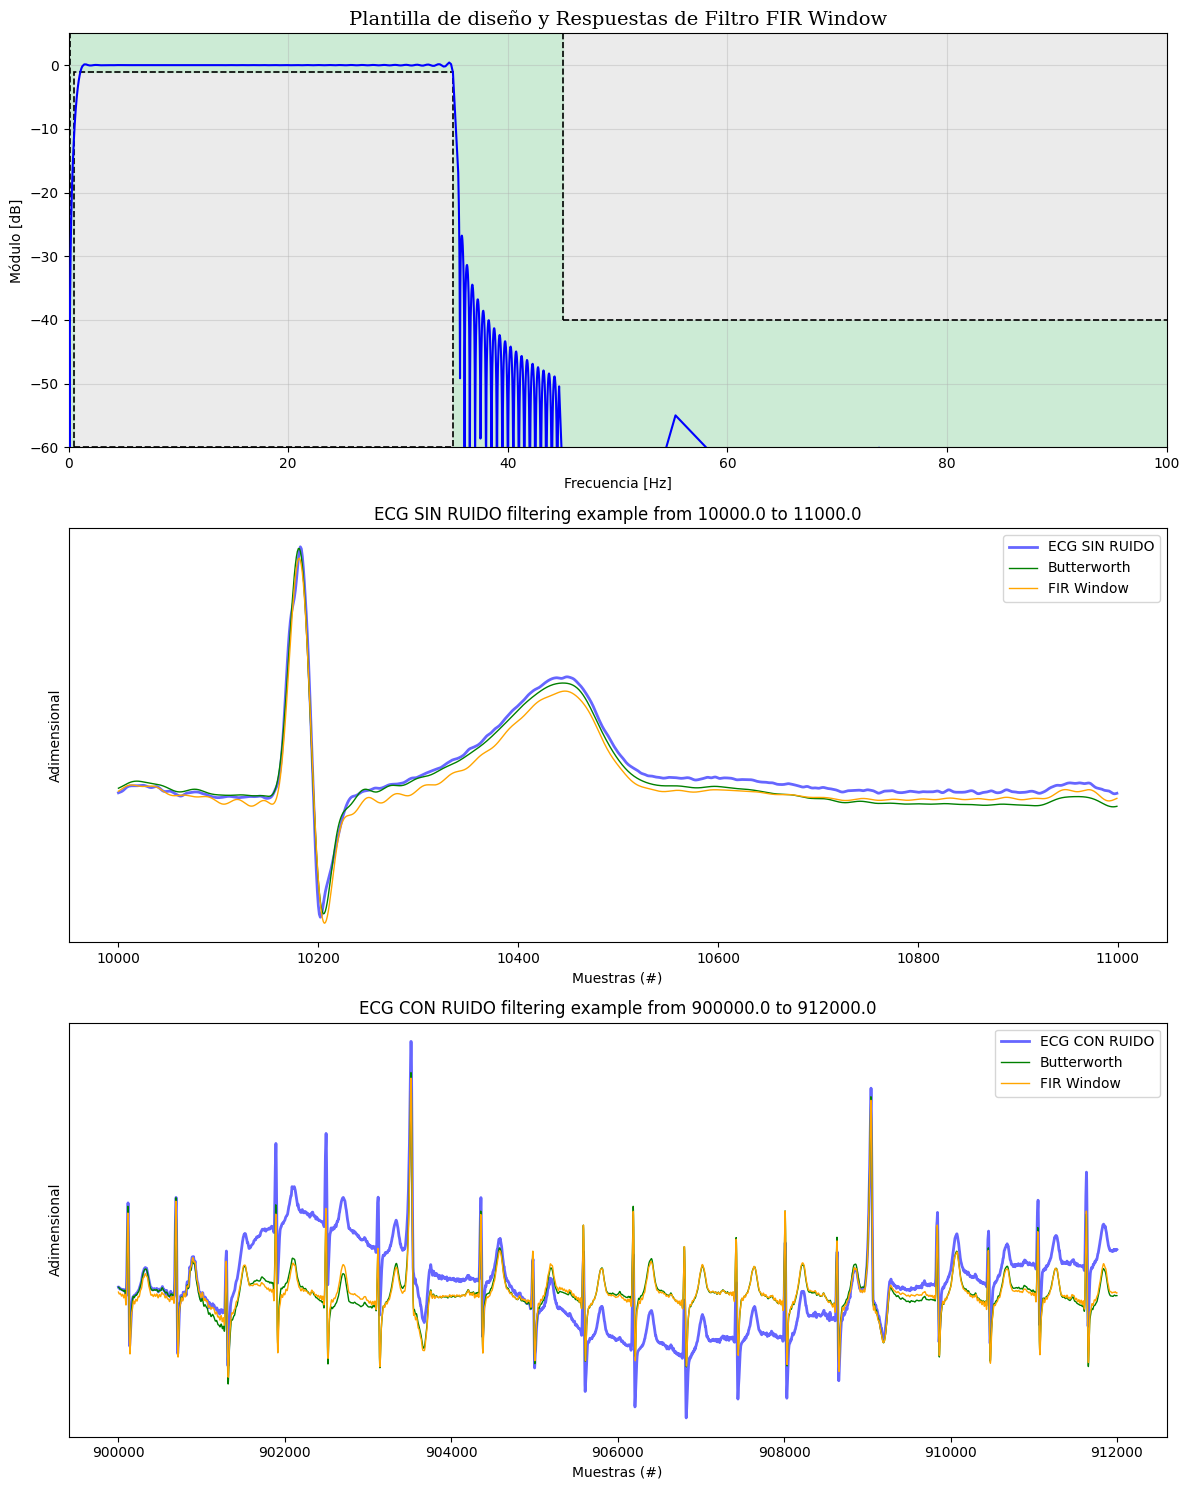

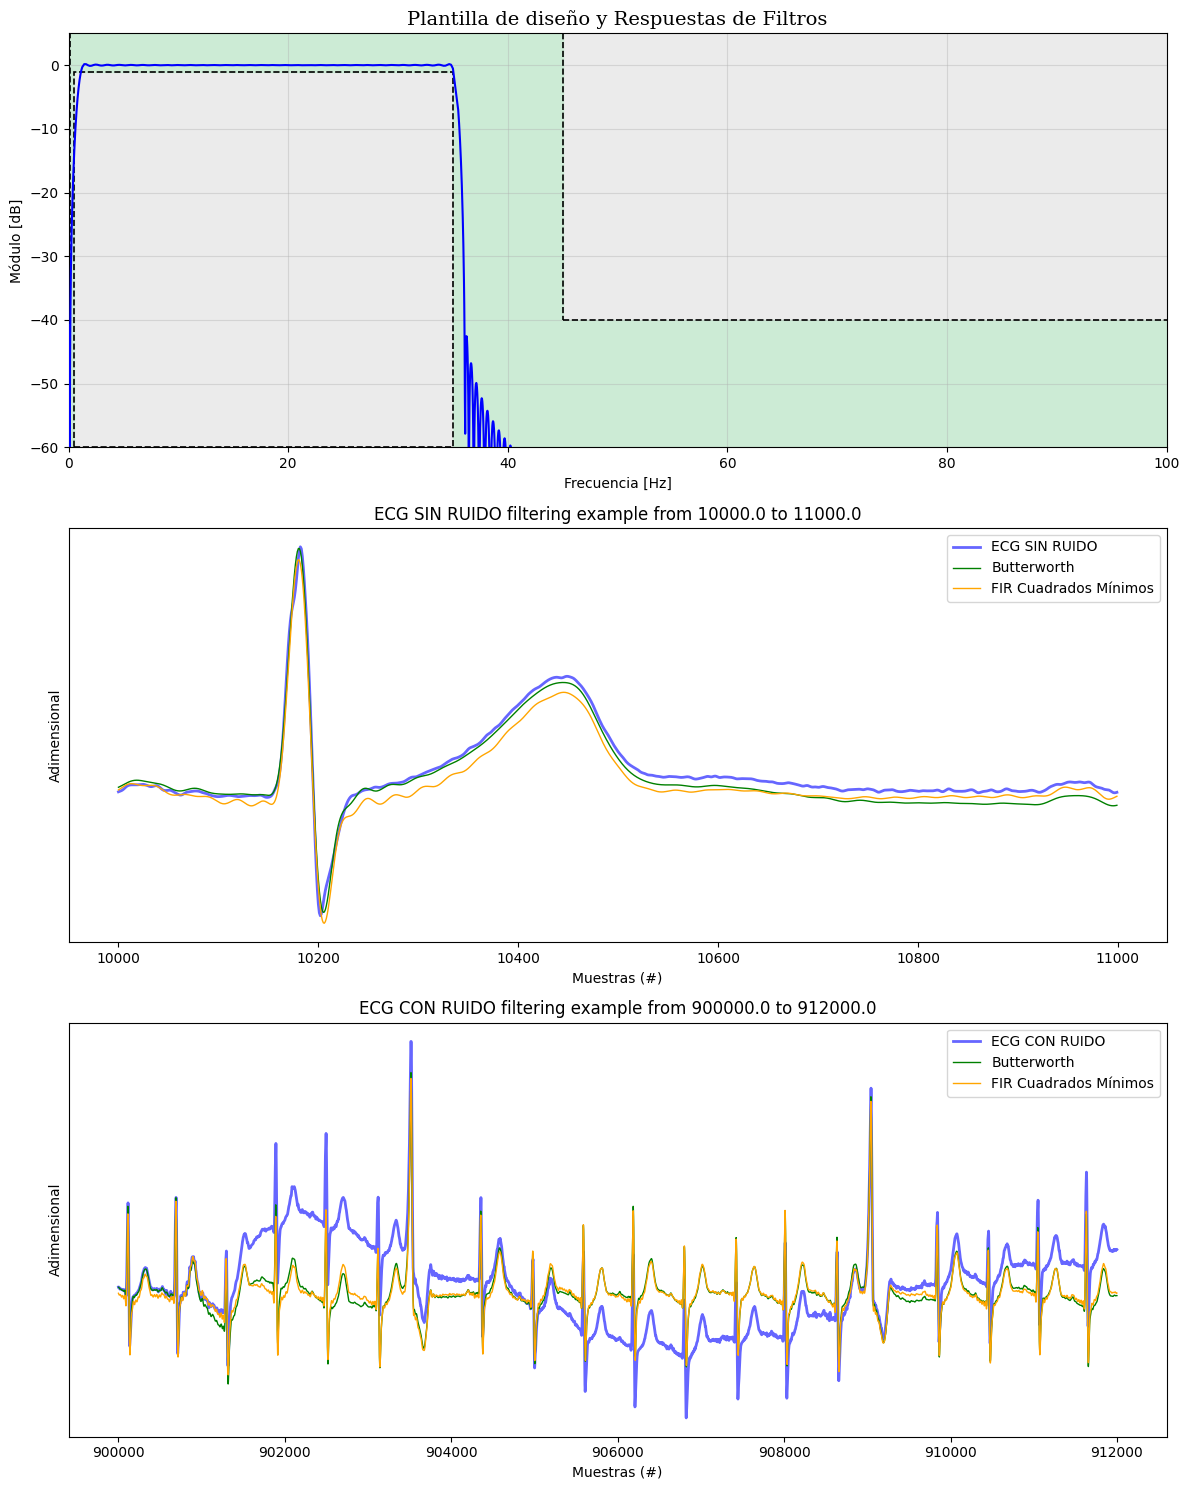

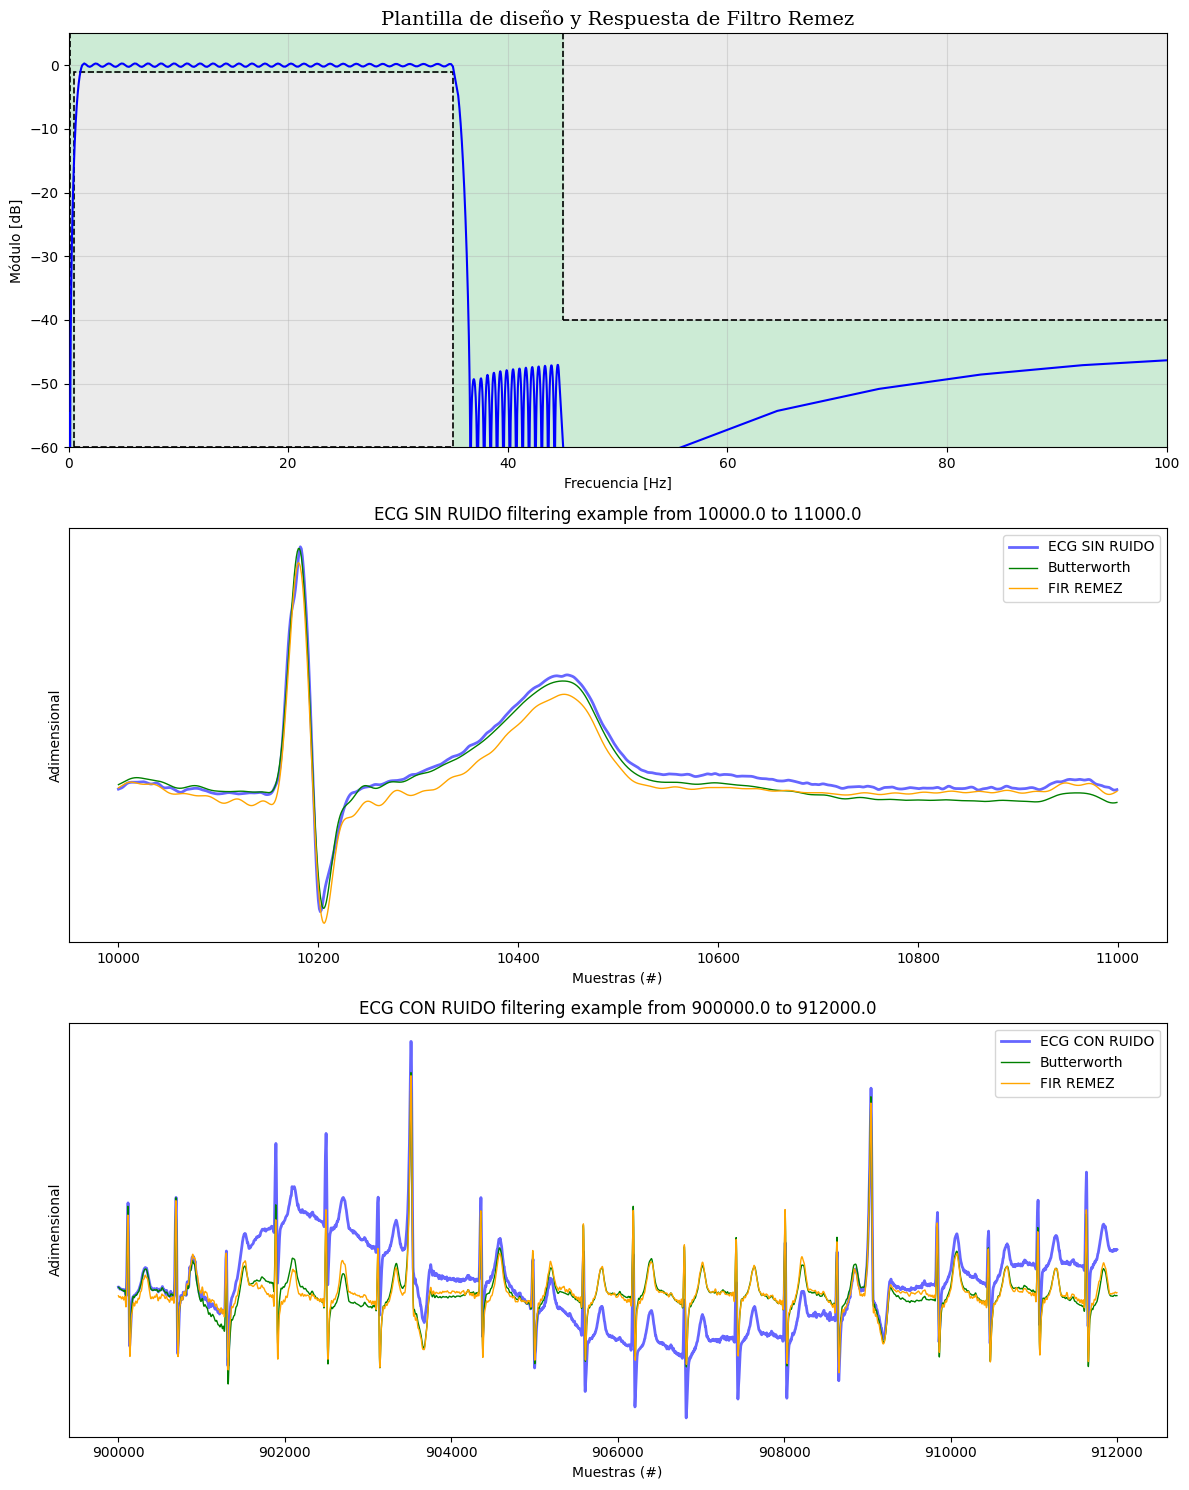

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig
import scipy.io as sio
import matplotlib.patches as patches
import matplotlib.lines as mlines

# ----- DISEÑO FILTRO FIR WINDOW -----
fs_ecg = 1000
mat_struct = sio.loadmat('./ECG_TP4.mat')
ecg_one_lead = mat_struct['ecg_lead'].flatten()
cant_muestras = len(ecg_one_lead)

fs = 1000
ripple = 1 

ws1 = .2 # STOP
wp1 = 1.2 # PASO
ws2 = 35.5 # STOP
wp2 = 35 # PASO

gpass = 1
gstop = 40

wp = [wp1, wp2]
ws = [ws1, ws2]

numtaps = 2000
demora = (numtaps-1)//2 

gains = np.array([0, 0, 1, 1, 0, 0])

if numtaps % 2 == 0:
    gains[-1] = 0. 
    
b_win = sig.firwin2(numtaps, 
                    freq = np.array([0., ws1,  wp1,   wp2,   ws2,    fs//2]), 
                    gain = gains, 
                    fs = fs,
                    window = 'boxcar',
                    antisymmetric= False)

ww = np.concatenate([
    np.logspace(start=-2, stop=0.1, num=500), 
    np.linspace(start=1.26, stop=35, num=200),
    np.logspace(start=1.55, stop=1.65, num=300),
    np.linspace(start=46, stop=fs//2, num=50)]) 

zeros, poles, gain = sig.tf2zpk(b_win,a = 1)
w_win, h_win = sig.freqz(b_win, worN=ww, fs=fs) 

# ----- DISEÑO FILTRO BUTTERWORTH -----
fs_butter = 1000

ws1_butter = .1 # STOP
wp1_butter = .5 # PASO
ws2_butter = 45 # STOP
wp2_butter = 35 # PASO

gpass_butter = 1
gstop_butter = 40

wp_butter = [wp1_butter, wp2_butter]
ws_butter = [ws1_butter, ws2_butter]

sos_coeff_butt = sig.iirdesign(wp=wp_butter, ws=ws_butter, gpass=gpass_butter/2, gstop=gstop_butter/2, analog=False, ftype='butter', output='sos', fs=fs_butter)

w_butt, h_butt = sig.sosfreqz(sos_coeff_butt, worN=ww, fs=fs_butter)

yy_butt = sig.sosfiltfilt(sos_coeff_butt, ecg_one_lead)
ECG_f_butt = yy_butt
ECG_f_win = sig.lfilter(b_win, 1., ecg_one_lead)

'------GRAFICO------'
fig, axs = plt.subplots(3, 1, figsize=(12, 15))

ax_plantilla = axs[0]
ax_plantilla.set_facecolor('#ebebeb') 

ax_plantilla.fill_between([0, ws1_butter], -60, -gstop_butter, color='#ccebd5', zorder=1)
ax_plantilla.fill_between([ws1_butter, wp1_butter], -60, 5, color='#ccebd5', zorder=1)
ax_plantilla.fill_between([wp1_butter, wp2_butter], -ripple, 5, color='#ccebd5', zorder=1)
ax_plantilla.fill_between([wp2_butter, ws2_butter], -60, 5, color='#ccebd5', zorder=1)
ax_plantilla.fill_between([ws2_butter, fs_butter//2], -60, -gstop_butter, color='#ccebd5', zorder=1)

rect_stop1 = patches.Rectangle((0, -gstop_butter), ws1_butter, 5 - (-gstop_butter), 
                               linewidth=1.2, edgecolor='black', linestyle='--', facecolor='none', zorder=2)
ax_plantilla.add_patch(rect_stop1)

rect_pass = patches.Rectangle((wp1_butter, -60), wp2_butter - wp1_butter, (-ripple) - (-60), 
                              linewidth=1.2, edgecolor='black', linestyle='--', facecolor='none', zorder=2)
ax_plantilla.add_patch(rect_pass)

rect_stop2 = patches.Rectangle((ws2_butter, -gstop_butter), (fs_butter//2) - ws2_butter, 5 - (-gstop_butter), 
                               linewidth=1.2, edgecolor='black', linestyle='--', facecolor='none', zorder=2)
ax_plantilla.add_patch(rect_stop2)

mag_db_win = 20 * np.log10(np.maximum(np.abs(h_win), 1e-12))

ax_plantilla.plot(w_win, mag_db_win, color='blue', linewidth=1.5, label='FIR Window', zorder=3)

ax_plantilla.set_title("Plantilla de diseño y Respuestas de Filtro FIR Window", fontfamily='serif', fontsize=14)
ax_plantilla.set_xlabel("Frecuencia [Hz]")
ax_plantilla.set_ylabel("Módulo [dB]")
ax_plantilla.set_xlim(0, 100) 
ax_plantilla.set_ylim(-60, 5)
ax_plantilla.grid(True, linestyle='-', alpha=0.4, zorder=0)

green_patch = patches.Patch(color='#ccebd5', label='bw digital')
dashed_line = mlines.Line2D([], [], color='none', markeredgecolor='black', marker='s', markersize=12, markeredgewidth=1.2, linestyle='--', label='Plantilla')
blue_line = mlines.Line2D([], [], color='blue', linewidth=1.5, label='FIR Window')

'----COMPARACION FILTRO----'
ii_sin_ruido = [10e3, 11e3] 
zoom_region = np.arange(np.max([0, ii_sin_ruido[0]]), np.min([cant_muestras, ii_sin_ruido[1]]), dtype='uint')

axs[1].plot(zoom_region, ecg_one_lead[zoom_region], label='ECG SIN RUIDO', color='blue', alpha=0.6, linewidth=2)
axs[1].plot(zoom_region, ECG_f_butt[zoom_region], label='Butterworth', color='green', linewidth=1)
axs[1].plot(zoom_region, ECG_f_win[zoom_region + demora], label='FIR Window', color='orange', linewidth=1)

axs[1].set_title('ECG SIN RUIDO filtering example from ' + str(ii_sin_ruido[0]) + ' to ' + str(ii_sin_ruido[1]))
axs[1].set_ylabel('Adimensional')
axs[1].set_xlabel('Muestras (#)')
axs[1].legend(loc='upper right')
axs[1].set_yticks(())

ii_con_ruido = np.array([15, 15.2]) * 60 * fs 
zoom_region = np.arange(np.max([0, ii_con_ruido[0]]), np.min([cant_muestras, ii_con_ruido[1]]), dtype='uint')

axs[2].plot(zoom_region, ecg_one_lead[zoom_region], label='ECG CON RUIDO', color='blue', alpha=0.6, linewidth=2)
axs[2].plot(zoom_region, ECG_f_butt[zoom_region], label='Butterworth', color='green', linewidth=1)
axs[2].plot(zoom_region, ECG_f_win[zoom_region + demora], label='FIR Window', color='orange', linewidth=1)

axs[2].set_title('ECG CON RUIDO filtering example from ' + str(ii_con_ruido[0]) + ' to ' + str(ii_con_ruido[1]))
axs[2].set_ylabel('Adimensional')
axs[2].set_xlabel('Muestras (#)')
axs[2].legend(loc='upper right')
axs[2].set_yticks(())

plt.tight_layout()
plt.show()

# ----- DISEÑO FILTRO CUADRADOS MINIMOS -----
fs_ecg = 1000
mat_struct = sio.loadmat('./ECG_TP4.mat')

ecg_one_lead = mat_struct['ecg_lead'].flatten()

fs = 1000
ripple = 1 

ws1 = .2 #STOP
wp1 = 1.2 #PASO
 
ws2 = 36 #STOP
wp2 = 35  

gpass = 1
gstop = 40

wp = [wp1, wp2]
ws = [ws1, ws2]

numtaps = 1851 

demora = (numtaps-1)//2 

gains = np.array([0, 0, 1, 1, 0, 0])

if numtaps % 2 == 0:
    gains[-1] = 0. 
    

b_cuadrados_minimos = sig.firls(numtaps, 
                  bands = np.array([0., ws1,  wp1,   wp2,   ws2,    fs//2]),
                  desired = gains, 
                  weight = np.array([15,1,7]),
                  fs = fs) 

ww = np.concatenate([
    np.logspace(start=-2, stop=0.1, num=500), 
    np.linspace(start=1.26, stop=35, num=200),
    np.logspace(start=1.55, stop=1.65, num=300),
    np.linspace(start=46, stop=fs//2, num=50)]) 


zeros, poles, gain = sig.tf2zpk(b_cuadrados_minimos,a = 1)

w_cuadrados_minimos, h_cuadrados_minimos = sig.freqz(b_cuadrados_minimos, worN=ww, fs=fs) # w son las frecuencias, H es la respuesta compleja

fs_butter = 1000

ws1_butter = .1 # STOP
wp1_butter = .5 # PASO
ws2_butter = 45 # STOP
wp2_butter = 35 # PASO

gpass_butter = 1
gstop_butter = 40

wp_butter = [wp1_butter, wp2_butter]
ws_butter = [ws1_butter, ws2_butter]

sos_coeff_butt = sig.iirdesign(wp=wp_butter, ws=ws_butter, gpass=gpass_butter/2, gstop=gstop_butter/2, analog=False, ftype='butter', output='sos', fs=fs_butter)

w_butt, h_butt = sig.sosfreqz(sos_coeff_butt, worN=ww, fs=fs_butter)

yy_butt = sig.sosfiltfilt(sos_coeff_butt, ecg_one_lead)
ECG_f_butt = yy_butt
ECG_f_cuadrados_minimos = sig.lfilter(b_cuadrados_minimos, 1., ecg_one_lead)


'------GRAFICO------'
fig, axs = plt.subplots(3, 1, figsize=(12, 15))

ax_plantilla = axs[0]
ax_plantilla.set_facecolor('#ebebeb') 

ax_plantilla.fill_between([0, ws1_butter], -60, -gstop_butter, color='#ccebd5', zorder=1)
ax_plantilla.fill_between([ws1_butter, wp1_butter], -60, 5, color='#ccebd5', zorder=1)
ax_plantilla.fill_between([wp1_butter, wp2_butter], -ripple, 5, color='#ccebd5', zorder=1)
ax_plantilla.fill_between([wp2_butter, ws2_butter], -60, 5, color='#ccebd5', zorder=1)
ax_plantilla.fill_between([ws2_butter, fs_butter//2], -60, -gstop_butter, color='#ccebd5', zorder=1)

rect_stop1 = patches.Rectangle((0, -gstop_butter), ws1_butter, 5 - (-gstop_butter), 
                               linewidth=1.2, edgecolor='black', linestyle='--', facecolor='none', zorder=2)
ax_plantilla.add_patch(rect_stop1)

rect_pass = patches.Rectangle((wp1_butter, -60), wp2_butter - wp1_butter, (-ripple) - (-60), 
                              linewidth=1.2, edgecolor='black', linestyle='--', facecolor='none', zorder=2)
ax_plantilla.add_patch(rect_pass)

rect_stop2 = patches.Rectangle((ws2_butter, -gstop_butter), (fs_butter//2) - ws2_butter, 5 - (-gstop_butter), 
                               linewidth=1.2, edgecolor='black', linestyle='--', facecolor='none', zorder=2)
ax_plantilla.add_patch(rect_stop2)

mag_db_cuadrados_minimos = 20 * np.log10(np.maximum(np.abs(h_cuadrados_minimos), 1e-12))

ax_plantilla.plot(w_cuadrados_minimos, mag_db_cuadrados_minimos, color='blue', linewidth=1.5, label='FIR Window', zorder=3)

ax_plantilla.set_title("Plantilla de diseño y Respuestas de Filtros", fontfamily='serif', fontsize=14)
ax_plantilla.set_xlabel("Frecuencia [Hz]")
ax_plantilla.set_ylabel("Módulo [dB]")
ax_plantilla.set_xlim(0, 100) 
ax_plantilla.set_ylim(-60, 5)
ax_plantilla.grid(True, linestyle='-', alpha=0.4, zorder=0)

green_patch = patches.Patch(color='#ccebd5', label='bw digital')
dashed_line = mlines.Line2D([], [], color='none', markeredgecolor='black', marker='s', markersize=12, markeredgewidth=1.2, linestyle='--', label='Plantilla')
blue_line = mlines.Line2D([], [], color='blue', linewidth=1.5, label='FIR Cuadrados Mínimos')

regs_interes = (
        np.array([5, 5.2]) *60*fs, # minutos a muestras
        np.array([12, 12.4]) *60*fs, # minutos a muestras
        np.array([15, 15.2]) *60*fs, # minutos a muestras
        )
 

'----COMPARACION FILTRO----'
ii_sin_ruido = [10e3, 11e3] 
zoom_region = np.arange(np.max([0, ii_sin_ruido[0]]), np.min([cant_muestras, ii_sin_ruido[1]]), dtype='uint')

axs[1].plot(zoom_region, ecg_one_lead[zoom_region], label='ECG SIN RUIDO', color='blue', alpha=0.6, linewidth=2)
axs[1].plot(zoom_region, ECG_f_butt[zoom_region], label='Butterworth', color='green', linewidth=1)
axs[1].plot(zoom_region, ECG_f_cuadrados_minimos[zoom_region + demora], label='FIR Cuadrados Mínimos', color='orange', linewidth=1)

axs[1].set_title('ECG SIN RUIDO filtering example from ' + str(ii_sin_ruido[0]) + ' to ' + str(ii_sin_ruido[1]))
axs[1].set_ylabel('Adimensional')
axs[1].set_xlabel('Muestras (#)')
axs[1].legend(loc='upper right')
axs[1].set_yticks(())


ii_con_ruido = np.array([15, 15.2]) * 60 * fs 
zoom_region = np.arange(np.max([0, ii_con_ruido[0]]), np.min([cant_muestras, ii_con_ruido[1]]), dtype='uint')

axs[2].plot(zoom_region, ecg_one_lead[zoom_region], label='ECG CON RUIDO', color='blue', alpha=0.6, linewidth=2)
axs[2].plot(zoom_region, ECG_f_butt[zoom_region], label='Butterworth', color='green', linewidth=1)
axs[2].plot(zoom_region, ECG_f_cuadrados_minimos[zoom_region + demora], label='FIR Cuadrados Mínimos', color='orange', linewidth=1)

axs[2].set_title('ECG CON RUIDO filtering example from ' + str(ii_con_ruido[0]) + ' to ' + str(ii_con_ruido[1]))
axs[2].set_ylabel('Adimensional')
axs[2].set_xlabel('Muestras (#)')
axs[2].legend(loc='upper right')
axs[2].set_yticks(())

plt.tight_layout()
plt.show()

'-----DISEÑO FILTRO REMEZ----'
fs_ecg = 1000
mat_struct = sio.loadmat('./ECG_TP4.mat')

ecg_one_lead = mat_struct['ecg_lead'].flatten()

fs = 1000
ripple = 1 

ws1 = .2 #STOP
wp1 = 1.2 #PASO
 
ws2 = 36.5 #STOP
wp2 = 35  

gpass = 1
gstop = 40

wp = [wp1, wp2]
ws = [ws1, ws2]

numtaps = 1721

demora = (numtaps-1)//2 

gains_remez = np.array([0, 1, 0])

if numtaps % 2 == 0:
    gains_remez[-1] = 0. 

b_remez = sig.remez(numtaps, 
                  bands = np.array([0., ws1,  wp1,   wp2,   ws2,    fs//2]),
                  desired = gains_remez,
                  fs = fs,
                  weight = ([7,1,25]),
                  type = 'hilbert') 

ww = np.concatenate([
    np.logspace(start=-2, stop=0.1, num=500), 
    np.linspace(start=1.26, stop=35, num=200),
    np.logspace(start=1.55, stop=1.65, num=300),
    np.linspace(start=46, stop=fs//2, num=50)]) 


zeros, poles, gain = sig.tf2zpk(b_remez,a = 1)

w_remez, h_remez = sig.freqz(b_remez, worN=ww, fs=fs) 

fs_butter = 1000

ws1_butter = .1 # STOP
wp1_butter = .5 # PASO
ws2_butter = 45 # STOP
wp2_butter = 35 # PASO

gpass_butter = 1
gstop_butter = 40

wp_butter = [wp1_butter, wp2_butter]
ws_butter = [ws1_butter, ws2_butter]

sos_coeff_butt = sig.iirdesign(wp=wp_butter, ws=ws_butter, gpass=gpass_butter/2, gstop=gstop_butter/2, analog=False, ftype='butter', output='sos', fs=fs_butter)

w_butt, h_butt = sig.sosfreqz(sos_coeff_butt, worN=ww, fs=fs_butter)

yy_butt = sig.sosfiltfilt(sos_coeff_butt, ecg_one_lead)
ECG_f_butt = yy_butt
ECG_f_remez = sig.filtfilt(b_remez, 1., ecg_one_lead)


'------GRAFICO------'
fig, axs = plt.subplots(3, 1, figsize=(12, 15))

ax_plantilla = axs[0]
ax_plantilla.set_facecolor('#ebebeb') 

ax_plantilla.fill_between([0, ws1_butter], -60, -gstop_butter, color='#ccebd5', zorder=1)
ax_plantilla.fill_between([ws1_butter, wp1_butter], -60, 5, color='#ccebd5', zorder=1)
ax_plantilla.fill_between([wp1_butter, wp2_butter], -ripple, 5, color='#ccebd5', zorder=1)
ax_plantilla.fill_between([wp2_butter, ws2_butter], -60, 5, color='#ccebd5', zorder=1)
ax_plantilla.fill_between([ws2_butter, fs_butter//2], -60, -gstop_butter, color='#ccebd5', zorder=1)

rect_stop1 = patches.Rectangle((0, -gstop_butter), ws1_butter, 5 - (-gstop_butter), 
                               linewidth=1.2, edgecolor='black', linestyle='--', facecolor='none', zorder=2)
ax_plantilla.add_patch(rect_stop1)

rect_pass = patches.Rectangle((wp1_butter, -60), wp2_butter - wp1_butter, (-ripple) - (-60), 
                              linewidth=1.2, edgecolor='black', linestyle='--', facecolor='none', zorder=2)
ax_plantilla.add_patch(rect_pass)

rect_stop2 = patches.Rectangle((ws2_butter, -gstop_butter), (fs_butter//2) - ws2_butter, 5 - (-gstop_butter), 
                               linewidth=1.2, edgecolor='black', linestyle='--', facecolor='none', zorder=2)
ax_plantilla.add_patch(rect_stop2)

mag_db_remez = 20 * np.log10(np.maximum(np.abs(h_remez), 1e-12))

ax_plantilla.plot(w_remez, mag_db_remez, color='blue', linewidth=1.5, label='FIR Window', zorder=3)

ax_plantilla.set_title("Plantilla de diseño y Respuesta de Filtro Remez", fontfamily='serif', fontsize=14)
ax_plantilla.set_xlabel("Frecuencia [Hz]")
ax_plantilla.set_ylabel("Módulo [dB]")
ax_plantilla.set_xlim(0, 100) 
ax_plantilla.set_ylim(-60, 5)
ax_plantilla.grid(True, linestyle='-', alpha=0.4, zorder=0)

green_patch = patches.Patch(color='#ccebd5', label='bw digital')
dashed_line = mlines.Line2D([], [], color='none', markeredgecolor='black', marker='s', markersize=12, markeredgewidth=1.2, linestyle='--', label='Plantilla')
blue_line = mlines.Line2D([], [], color='blue', linewidth=1.5, label='FIR REMEZ')

regs_interes = (
        np.array([5, 5.2]) *60*fs, # minutos a muestras
        np.array([12, 12.4]) *60*fs, # minutos a muestras
        np.array([15, 15.2]) *60*fs, # minutos a muestras
        )
 

'----COMPARACION FILTRO----'
ii_sin_ruido = [10e3, 11e3] 
zoom_region = np.arange(np.max([0, ii_sin_ruido[0]]), np.min([cant_muestras, ii_sin_ruido[1]]), dtype='uint')

axs[1].plot(zoom_region, ecg_one_lead[zoom_region], label='ECG SIN RUIDO', color='blue', alpha=0.6, linewidth=2)
axs[1].plot(zoom_region, ECG_f_butt[zoom_region], label='Butterworth', color='green', linewidth=1)
axs[1].plot(zoom_region, ECG_f_remez[zoom_region], label='FIR REMEZ', color='orange', linewidth=1)

axs[1].set_title('ECG SIN RUIDO filtering example from ' + str(ii_sin_ruido[0]) + ' to ' + str(ii_sin_ruido[1]))
axs[1].set_ylabel('Adimensional')
axs[1].set_xlabel('Muestras (#)')
axs[1].legend(loc='upper right')
axs[1].set_yticks(())


ii_con_ruido = np.array([15, 15.2]) * 60 * fs 
zoom_region = np.arange(np.max([0, ii_con_ruido[0]]), np.min([cant_muestras, ii_con_ruido[1]]), dtype='uint')

axs[2].plot(zoom_region, ecg_one_lead[zoom_region], label='ECG CON RUIDO', color='blue', alpha=0.6, linewidth=2)
axs[2].plot(zoom_region, ECG_f_butt[zoom_region], label='Butterworth', color='green', linewidth=1)
axs[2].plot(zoom_region, ECG_f_remez[zoom_region], label='FIR REMEZ', color='orange', linewidth=1)

axs[2].set_title('ECG CON RUIDO filtering example from ' + str(ii_con_ruido[0]) + ' to ' + str(ii_con_ruido[1]))
axs[2].set_ylabel('Adimensional')
axs[2].set_xlabel('Muestras (#)')
axs[2].legend(loc='upper right')
axs[2].set_yticks(())

plt.tight_layout()
plt.show()

Para todos los FIR se empleó una plantilla más estricta para que después si cumple con esa plantilla va a cumplir con la plantilla original especificada al inicio del trabajo. Para todos los filtros de respuesta finita se emplearon diferentes plantillas debido a que no todas podían cumplir con los mismos parámetros. La ventaja que tienen los métodos de cuadrados mínimos como el método de Remez es que se le puede colocar pesos a cada banda sin necesidad de relajar alguna de ellas. 

Para el filtro de respuesta finita ventaneado se utilizó un filtro de tipo II debido a que se aprovechó su cero topológico en la frecuencia de Nyquist para utilizarlo a favor en el filtro pasabanda. Además, en el filtro realizado por el método de cuadrados mínimos se utilizó un filtro de tipo I y en el filtro que utilizó el método de Remez se utilizó un tipo III aprovechando sus ceros topológicos en el origen y en la frecuencia de Nyquist. 

También se puede observar cómo a medida que se fue cambiando de método, la cantidad de taps requeridos fue disminuyendo, es decir, el orden del filtro se fue reduciendo. El más eficiente computacionalmente entonces se podría considerar el de Remez.

Se utilizó como referencia la respuesta del filtro de Butterworth para poder analizar los filtros de respuesta finita. Los resultados obtenidos son los deseados debido a que todos los filtros tuvieron una respuesta muy similar a él y entre sí mismos. Lo que sí cambia es el costo computacional de cada uno y el tiempo de procesamiento de la señal. 

### Conclusión

En este trabajo práctico se analizaron y diseñaron filtros IIR y FIR basándonos en el filtrado de una señal de un electrocardiograma. 

Se implementó una plantilla común para todos, utilizando el método del cumplimiento de una plantilla más estricta para el caso de los FIRs. Además, se aprovecharon los ceros topológicos existentes en cada uno de ellos para su implementación.

Si bien todos los tipos de filtros cumplieron con el filtrado de la señal, es importante mencionar que los IIRs se mantienen como los más eficientes debido a que requieren muchísimo menos costo computacional y menos tiempo de procesamiento de la señal. Además, los filtros de respuesta al impulso infinita logran prácticamente los mismos resultados que los de respuesta finita al impulso, utilizando una cantidad considerablemente menor de órdenes.